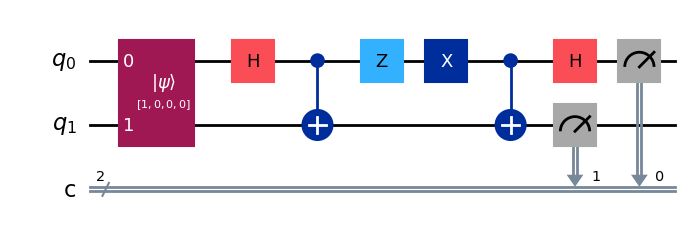

Alice send: 11
Bob received the bits: 11
Circuit ok


In [12]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from numpy import pi
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector

# Alice wants to send two classical qubits.

Class_bits = input("Enter the 2 classical bits Alice wants to send: ")
arr = list(Class_bits)

# Building the ckt

u = Statevector.from_label("00")

# Building the 2 - qubit register and 2- Classical Register

q_reg = QuantumRegister(2,"q")
c_reg = ClassicalRegister(2,"c")

# Building the quantum circuit

circuit_1 = QuantumCircuit(q_reg,c_reg)

# initializing the state that is to be transported

circuit_1.initialize(u,[0, 1])

circuit_1.h(0)
circuit_1.cx(q_reg[0],q_reg[1])

if arr[0] == '1':
    circuit_1.z(0)

if arr[1] == '1':
    circuit_1.x(0)

circuit_1.cx(q_reg[0],q_reg[1])
circuit_1.h(0)

circuit_1.measure([0, 1], [0, 1])

display(circuit_1.draw(output='mpl'))

# Simulating

sim = AerSimulator()

result = sim.run(circuit_1, shots=1).result()

counts = result.get_counts()

creg_array = list(list(counts.keys())[0])

bob_received = ''.join(creg_array)

print("Alice send:", ''.join(arr))
print("Bob received the bits:", bob_received)

if ''.join(arr) == bob_received:
    print("Circuit ok")